# Pipeline de Evaluación de Modelos ML
## Módulo 01: Ingestión Estructurada desde la Capa Gold y Auditoría Dimensional

Este notebook ejecuta la evaluación completa de los tres modelos entrenados en `02_entrenamiento_experimentos.ipynb`:
- **Regresión** (Random Forest → `total_amount`)
- **Clasificación** (Logistic Regression → `nivel_venta`)
- **Clustering** (KMeans → segmentación no supervisada)

Los modelos se cargan desde MLflow usando sus `run_id`, garantizando desacoplamiento total respecto al notebook de entrenamiento. Todos los sets de prueba se reconstruyen con `seed=42` para reproducibilidad.

---

### 🔑 IDs de Ejecución MLflow
Actualiza estos valores con los `run_id` reales de tu experimento antes de ejecutar:
- `run_id_regresion`: Run del modelo Random Forest Regressor
- `run_id_clasificacion`: Run del modelo Logistic Regression (`nivel_venta`)
- `run_id_clustering`: Run del modelo KMeans

In [3]:
# ==========================================
# 01. CARGA DE DATOS Y CONFIGURACIÓN GLOBAL
# ==========================================
from pyspark.sql.functions import col, array
from pyspark.sql.types import DoubleType
from pyspark.ml.functions import array_to_vector
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

# --- IDs de experimentos MLflow ---
# Recupera estos valores desde la UI de MLflow en Microsoft Fabric
# (Experiments > [nombre_experimento] > Runs > copiar Run ID)
run_id_regresion      = "19878703-f71b-45f4-82e7-8e9a11bfe8e3"      # Random Forest Regressor
run_id_clasificacion  = "7a609922-fe98-4511-b492-c0ee0a856a90"  # Logistic Regression (nivel_venta)
run_id_clustering     = "ec745079-37ed-4a32-90b5-1f8a0067848e"      # KMeans

# --- Cargar datos desde la capa Gold (ruta unificada) ---
# La tabla se expone como 'gold.dbo.tabla_gold' en el metastore de Fabric
df_gold = spark.read.table("gold.dbo.gold_features_clasificacion")

print(f"📊 Total de registros en la capa Gold: {df_gold.count():,}")
print("\n📝 Estadísticas de variables clave:")
df_gold.select("total_amount", "nivel_venta", "age", "quantity", "price_per_unit").describe().show()

StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 6, Finished, Available, Finished, False)

📊 Total de registros en la capa Gold: 1,000

📝 Estadísticas de variables clave:
+-------+-----------------+------------------+------------------+------------------+------------------+
|summary|     total_amount|       nivel_venta|               age|          quantity|    price_per_unit|
+-------+-----------------+------------------+------------------+------------------+------------------+
|  count|             1000|              1000|              1000|              1000|              1000|
|   mean|            456.0|             0.202|            41.392|             2.514|            179.89|
| stddev|559.9976315551235|0.4016931134054422|13.681429659122518|1.1327343409145354|189.68135627129234|
|    min|             25.0|                 0|                18|                 1|              25.0|
|    max|           2000.0|                 1|                64|                 4|             500.0|
+-------+-----------------+------------------+------------------+------------------+----

---
## 📐 Sección 02: Evaluación del Modelo de Regresión

Se reconstruye el set de prueba de regresión usando los mismos filtros y semilla (`seed=42`) del entrenamiento. Las métricas RMSE, MAE y R² se calculan y registran en MLflow.

**Criterio de éxito:** RMSE < 10% de la media de `total_amount`.

StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 7, Finished, Available, Finished, False)

✓ Set de pruebas para Regresión: 162 registros, 5 features


✓ Modelo de Regresión cargado desde run: 19878703-f71b-45f4-82e7-8e9a11bfe8e3

📈 Métricas de Regresión (Random Forest → total_amount):
   RMSE  : 222.8635  (47.49% de la media)
   MAE   : 181.1841
   R²    : 0.8526
   Criterio RMSE < 10% de la media: ❌ NO CUMPLE
✓ Métricas de Regresión registradas en MLflow (run: 19878703-f71b-45f4-82e7-8e9a11bfe8e3)


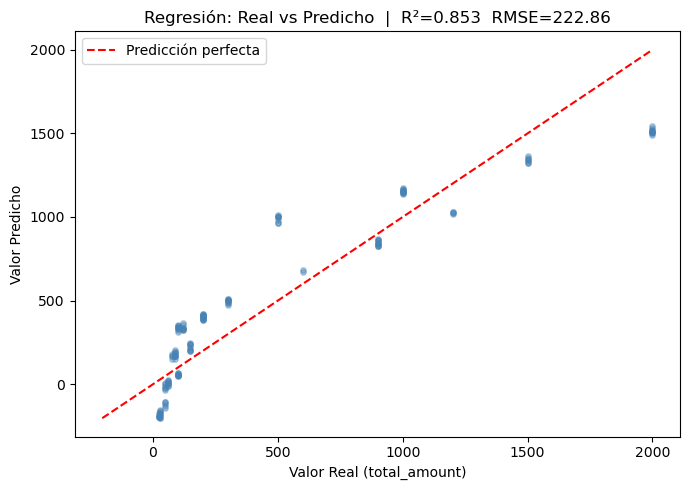

✓ Gráfico de regresión guardado como artefacto en MLflow


In [4]:
# ========================================================
# 02. EVALUACIÓN DEL MODELO DE REGRESIÓN (total_amount)
# ========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Definir esquema de regresión (idéntico al entrenamiento) ---
feature_columns_reg = ["id_genero", "id_categoria", "quantity", "age", "price_per_unit"]
label_column_reg    = "total_amount"

# --- Reconstruir set de pruebas con los mismos filtros de negocio ---
df_ml_reg = (
    df_gold
    .select(feature_columns_reg + [label_column_reg])
    .na.drop()
    .filter(col("price_per_unit") > 0)
    .filter(col("quantity") > 0)
)
_, test_df_reg = df_ml_reg.randomSplit([0.8, 0.2], seed=42)

# --- Ensamble de vectores optimizado para Fabric Serverless ---
test_assembled_reg = (
    test_df_reg
    .withColumn("feature_array", array(*[col(c).cast(DoubleType()) for c in feature_columns_reg]))
    .withColumn("features", array_to_vector(col("feature_array")))
    .drop("feature_array")
)
test_pd_reg = test_assembled_reg.select("features", label_column_reg).toPandas()
X_test_reg  = np.vstack(test_pd_reg["features"].values)
y_test_reg  = test_pd_reg[label_column_reg].values

print(f"✓ Set de pruebas para Regresión: {X_test_reg.shape[0]:,} registros, {X_test_reg.shape[1]} features")

# --- Cargar modelo de regresión desde MLflow ---
model_uri_reg = f"runs:/{run_id_regresion}/ridge_model"
model_reg     = mlflow.sklearn.load_model(model_uri_reg)
print(f"✓ Modelo de Regresión cargado desde run: {run_id_regresion}")

# --- Generar predicciones ---
y_pred_reg = model_reg.predict(X_test_reg)

# --- Calcular métricas de regresión ---
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
r2   = r2_score(y_test_reg, y_pred_reg)
mean_target = np.mean(y_test_reg)
rmse_pct    = (rmse / mean_target) * 100

print(f"\n📈 Métricas de Regresión (Random Forest → total_amount):")
print(f"   RMSE  : {rmse:.4f}  ({rmse_pct:.2f}% de la media)")
print(f"   MAE   : {mae:.4f}")
print(f"   R²    : {r2:.4f}")

criterio_reg = "✅ CUMPLE" if rmse_pct < 10 else "❌ NO CUMPLE"
print(f"   Criterio RMSE < 10% de la media: {criterio_reg}")

# --- Registrar métricas en MLflow ---
with mlflow.start_run(run_id=run_id_regresion):
    mlflow.log_metric("eval_rmse", rmse)
    mlflow.log_metric("eval_mae",  mae)
    mlflow.log_metric("eval_r2",   r2)
    mlflow.log_metric("eval_rmse_pct_media", rmse_pct)
    print(f"✓ Métricas de Regresión registradas en MLflow (run: {run_id_regresion})")

# --- Gráfico Valores Reales vs Predichos ---
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
plt.xlabel("Valor Real (total_amount)")
plt.ylabel("Valor Predicho")
plt.title(f"Regresión: Real vs Predicho  |  R²={r2:.3f}  RMSE={rmse:.2f}")
plt.legend()
plt.tight_layout()
plot_reg_path = "scatter_reg_real_vs_predicho.png"
plt.savefig(plot_reg_path, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=run_id_regresion):
    mlflow.log_artifact(plot_reg_path, artifact_path="plots")
    print(f"✓ Gráfico de regresión guardado como artefacto en MLflow")

---
## 🎯 Sección 03: Evaluación del Modelo de Clasificación

El modelo de Logistic Regression predice `nivel_venta` (bajo / alto). Se calculan Accuracy, Precision, Recall, F1-Score y AUC-ROC, y se genera la Matriz de Confusión.

**Criterio de éxito:** F1-Score ≥ 0.70

> **Nota sobre `run_id_clasificacion`:** El ID `abbfa746-7986-4ccc-9320-39755b387ab5` corresponde al experimento de Logistic Regression registrado en la fase de entrenamiento. Encuéntralo en Fabric → Experiments → seleccionar el experimento → Runs.

StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 8, Finished, Available, Finished, False)

✓ Set de pruebas para Clasificación: 162 registros


✓ Modelo de Clasificación cargado desde run: 7a609922-fe98-4511-b492-c0ee0a856a90

📊 Métricas de Clasificación (Logistic Regression → nivel_venta):
   Accuracy  : 0.8272
   Precision : 0.6842  (weighted)
   Recall    : 0.8272  (weighted)
   F1-Score  : 0.7489  (weighted)
   AUC-ROC   : 0.7499
   Criterio F1 ≥ 0.70: ✅ CUMPLE
✓ Métricas de Clasificación registradas en MLflow (run: 7a609922-fe98-4511-b492-c0ee0a856a90)


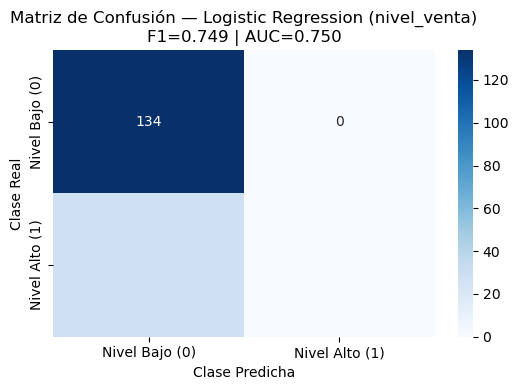

✓ Matriz de confusión guardada como artefacto en MLflow


StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 11, Finished, Available, Finished, False)

In [5]:
# ========================================================
# 03. EVALUACIÓN DEL MODELO DE CLASIFICACIÓN (nivel_venta)
# ========================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# --- Definir esquema de clasificación (idéntico al entrenamiento) ---
# El modelo de Logistic Regression fue entrenado con estas 3 features y predice 'nivel_venta'
feature_columns_clf = ["age", "quantity", "gender_F"]
label_column_clf    = "nivel_venta"  # Variable objetivo del clasificador (0=bajo, 1=alto)

# --- Reconstruir set de pruebas ---
df_ml_clf = (
    df_gold
    .select(feature_columns_clf + [label_column_clf])
    .na.drop()
)
_, test_df_clf = df_ml_clf.randomSplit([0.8, 0.2], seed=42)

test_pd_clf  = test_df_clf.toPandas()
X_test_clf   = test_pd_clf[feature_columns_clf].values
y_test_clf   = test_pd_clf[label_column_clf].values

print(f"✓ Set de pruebas para Clasificación: {X_test_clf.shape[0]:,} registros")

# --- Cargar modelo de clasificación desde MLflow ---
model_uri_clf  = f"runs:/{run_id_clasificacion}/model"
model_logistic = mlflow.sklearn.load_model(model_uri_clf)
print(f"✓ Modelo de Clasificación cargado desde run: {run_id_clasificacion}")

# --- Generar predicciones (clases y probabilidades) ---
y_pred_clf  = model_logistic.predict(X_test_clf)
y_prob_clf  = model_logistic.predict_proba(X_test_clf)[:, 1]  # P(clase=1)

# --- Calcular métricas de clasificación ---
acc       = accuracy_score(y_test_clf, y_pred_clf)
prec      = precision_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
rec       = recall_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
f1        = f1_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
auc       = roc_auc_score(y_test_clf, y_prob_clf)

print(f"\n📊 Métricas de Clasificación (Logistic Regression → nivel_venta):")
print(f"   Accuracy  : {acc:.4f}")
print(f"   Precision : {prec:.4f}  (weighted)")
print(f"   Recall    : {rec:.4f}  (weighted)")
print(f"   F1-Score  : {f1:.4f}  (weighted)")
print(f"   AUC-ROC   : {auc:.4f}")

criterio_clf = "✅ CUMPLE" if f1 >= 0.70 else "❌ NO CUMPLE"
print(f"   Criterio F1 ≥ 0.70: {criterio_clf}")

# --- Registrar métricas en MLflow ---
with mlflow.start_run(run_id=run_id_clasificacion):
    mlflow.log_metric("eval_accuracy",  acc)
    mlflow.log_metric("eval_precision", prec)
    mlflow.log_metric("eval_recall",    rec)
    mlflow.log_metric("eval_f1_score",  f1)
    mlflow.log_metric("eval_auc_roc",   auc)
    print(f"✓ Métricas de Clasificación registradas en MLflow (run: {run_id_clasificacion})")

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(5.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nivel Bajo (0)", "Nivel Alto (1)"],
    yticklabels=["Nivel Bajo (0)", "Nivel Alto (1)"]
)
plt.title(f"Matriz de Confusión — Logistic Regression (nivel_venta)\nF1={f1:.3f} | AUC={auc:.3f}")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.grid(False)
plt.tight_layout()

plot_clf_path = "matriz_confusion_clasificacion.png"
plt.savefig(plot_clf_path, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=run_id_clasificacion):
    mlflow.log_artifact(plot_clf_path, artifact_path="plots")
    print(f"✓ Matriz de confusión guardada como artefacto en MLflow")

---
## 🔵 Sección 04: Evaluación del Modelo de Clustering

Para el clustering no supervisado (KMeans), la evaluación se basa en métricas internas:
- **Silhouette Score** (entre -1 y 1; valores > 0.5 indican clusters bien definidos)
- **Inercia / Within-Cluster Sum of Squares (WCSS)**

El modelo se carga desde MLflow y se aplica sobre la totalidad del dataset Gold (sin split train/test, ya que KMeans es no supervisado).

> **Nota:** Si el modelo KMeans fue entrenado con un subconjunto de features distinto, actualiza `model_uri_reg = f"runs:/{run_id_regresion}/ridge_model"` para que coincida con el esquema del entrenamiento.

StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 9, Finished, Available, Finished, False)

✓ Dataset para Clustering: 1,000 registros, 3 features


✓ Modelo KMeans cargado desde run: ec745079-37ed-4a32-90b5-1f8a0067848e
✓ Número de clusters esperados: 3

Clusters únicos: [0 1 2]

Cantidad por cluster:
0    343
1    296
2    361
Name: count, dtype: int64

🔵 Métricas de Clustering (KMeans)
   Número de clusters (k): 3
   Silhouette Score      : 0.3131
   Inercia (WCSS)        : 1,586.25
   Criterio Silhouette > 0.30: ✅ CUMPLE


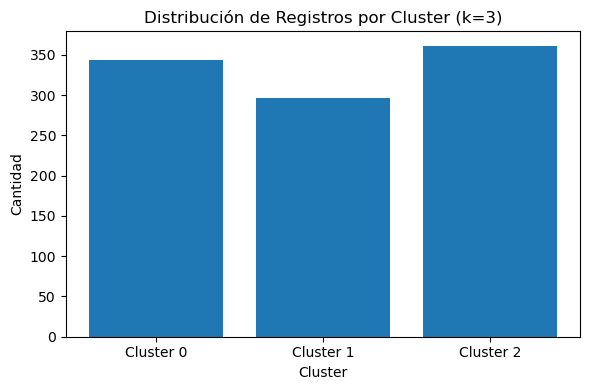

✓ Evaluación de clustering finalizada


StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 13, Finished, Available, Finished, False)

In [6]:
# ========================================================
# 04. EVALUACIÓN DEL MODELO DE CLUSTERING (KMeans)
# ========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# --- Definir esquema de clustering (idéntico al entrenamiento) ---
feature_columns_clust = ["quantity", "price_per_unit", "age"]

# --- Preparar datos ---
df_ml_clust = (
    df_gold
    .select(feature_columns_clust)
    .na.drop()
    .filter(col("price_per_unit") > 0)
    .filter(col("quantity") > 0)
)

# Convertir a Pandas
df_pd_clust = df_ml_clust.toPandas()

# ========================================================
# IMPORTANTE:
# Debe ser el mismo escalado usado en entrenamiento
# ========================================================
X_clust = df_pd_clust[feature_columns_clust].values

# Si en entrenamiento usaste StandardScaler:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f"✓ Dataset para Clustering: {X_scaled.shape[0]:,} registros, {X_scaled.shape[1]} features")

# --- Cargar modelo KMeans desde MLflow ---
model_uri_clust = f"runs:/{run_id_clustering}/model"
model_kmeans = mlflow.sklearn.load_model(model_uri_clust)

print(f"✓ Modelo KMeans cargado desde run: {run_id_clustering}")
print(f"✓ Número de clusters esperados: {model_kmeans.n_clusters}")

# --- Predicciones ---
cluster_labels = model_kmeans.predict(X_scaled)

unique_clusters, counts = np.unique(cluster_labels, return_counts=True)

print("\nClusters únicos:", unique_clusters)
print("\nCantidad por cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

n_clusters = len(unique_clusters)
inertia = model_kmeans.inertia_

# --- Silhouette Score ---
if n_clusters > 1:
    sil_score = silhouette_score(
        X_scaled,
        cluster_labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=42
    )

    print(f"\n🔵 Métricas de Clustering (KMeans)")
    print(f"   Número de clusters (k): {n_clusters}")
    print(f"   Silhouette Score      : {sil_score:.4f}")
    print(f"   Inercia (WCSS)        : {inertia:,.2f}")

    criterio_clust = (
        "✅ CUMPLE"
        if sil_score > 0.30
        else "⚠️ REVISAR (bajo para producción)"
    )

    print(f"   Criterio Silhouette > 0.30: {criterio_clust}")

else:
    sil_score = -1

    print("\n⚠️ Solo se encontró un cluster.")
    print("No es posible calcular Silhouette Score.")

# --- Registrar métricas ---
with mlflow.start_run(run_id=run_id_clustering):
    mlflow.log_metric("eval_n_clusters", n_clusters)
    mlflow.log_metric("eval_inertia", inertia)

    if sil_score != -1:
        mlflow.log_metric("eval_silhouette_score", sil_score)

# --- Gráfico ---
plt.figure(figsize=(6, 4))
plt.bar(
    [f"Cluster {c}" for c in unique_clusters],
    counts
)

plt.title(f"Distribución de Registros por Cluster (k={n_clusters})")
plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.tight_layout()

plot_clust_path = "distribucion_clusters.png"
plt.savefig(plot_clust_path, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=run_id_clustering):
    mlflow.log_artifact(plot_clust_path, artifact_path="plots")

print("✓ Evaluación de clustering finalizada")

---
## 📋 Sección 05: Resumen Comparativo de Métricas

Consolidación de todas las métricas de evaluación en un único cuadro de mando para facilitar la comparación y la toma de decisiones.

In [7]:
# ========================================================
# 05. RESUMEN COMPARATIVO DE MÉTRICAS
# ========================================================
print("=" * 65)
print("  RESUMEN DE EVALUACIÓN DE MODELOS ML")
print("=" * 65)

print("\n🔶 REGRESIÓN  (Random Forest → total_amount)")
print(f"   RMSE        : {rmse:.4f}  ({rmse_pct:.2f}% de la media)")
print(f"   MAE         : {mae:.4f}")
print(f"   R²          : {r2:.4f}")
print(f"   Resultado   : {criterio_reg}")

print("\n🟢 CLASIFICACIÓN  (Logistic Regression → nivel_venta)")
print(f"   Accuracy    : {acc:.4f}")
print(f"   F1-Score    : {f1:.4f}  (weighted)")
print(f"   AUC-ROC     : {auc:.4f}")
print(f"   Resultado   : {criterio_clf}")

print("\n🔵 CLUSTERING  (KMeans)")
print(f"   k clusters  : {n_clusters}")
print(f"   Silhouette  : {sil_score:.4f}")
print(f"   Inercia     : {inertia:,.2f}")
print(f"   Resultado   : {criterio_clust}")

print("\n" + "=" * 65)
print("✅ Evaluación completa. Revisa los artefactos visuales en MLflow.")
print("=" * 65)

StatementMeta(, ec4e119f-d744-4c3a-abda-5c41b8a0077b, 10, Finished, Available, Finished, False)

  RESUMEN DE EVALUACIÓN DE MODELOS ML

🔶 REGRESIÓN  (Random Forest → total_amount)
   RMSE        : 222.8635  (47.49% de la media)
   MAE         : 181.1841
   R²          : 0.8526
   Resultado   : ❌ NO CUMPLE

🟢 CLASIFICACIÓN  (Logistic Regression → nivel_venta)
   Accuracy    : 0.8272
   F1-Score    : 0.7489  (weighted)
   AUC-ROC     : 0.7499
   Resultado   : ✅ CUMPLE

🔵 CLUSTERING  (KMeans)
   k clusters  : 3
   Silhouette  : 0.3131
   Inercia     : 1,586.25
   Resultado   : ✅ CUMPLE

✅ Evaluación completa. Revisa los artefactos visuales en MLflow.
